In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 10
    learning_rate = 0.0001
    device = "mps" if torch.mps.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [11]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = nn.functional.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, backbone_name="resnet34", pretrained=True):
        super().__init__()

        if backbone_name == "resnet34":
            weights = torchvision.models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
            backbone = torchvision.models.resnet34(weights=weights)

            stem_ch = 64
            enc1_ch = 64
            enc2_ch = 128
            enc3_ch = 256
            enc4_ch = 512

        elif backbone_name == "resnet50":
            weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
            backbone = torchvision.models.resnet50(weights=weights)

            stem_ch = 64
            enc1_ch = 256
            enc2_ch = 512
            enc3_ch = 1024
            enc4_ch = 2048

        else:
            raise ValueError("backbone_name must be 'resnet34' or 'resnet50'")

        if in_channels != 3:
            backbone.conv1 = nn.Conv2d(
                in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False
            )

        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu
        )
        self.maxpool = backbone.maxpool
        self.encoder1 = backbone.layer1
        self.encoder2 = backbone.layer2
        self.encoder3 = backbone.layer3
        self.encoder4 = backbone.layer4

        self.bottleneck = DoubleConv(enc4_ch, 512)

        self.up4 = UpBlock(512, enc3_ch, 256)
        self.up3 = UpBlock(256, enc2_ch, 128)
        self.up2 = UpBlock(128, enc1_ch, 64)
        self.up1 = UpBlock(64, stem_ch, 64)

        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            DoubleConv(32, 32)
        )

        self.seg_head = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):

        s1 = self.stem(x)
        x = self.maxpool(s1)
        s2 = self.encoder1(x)
        s3 = self.encoder2(s2)
        s4 = self.encoder3(s3)
        x = self.encoder4(s4)

        x = self.bottleneck(x)

        x = self.up4(x, s4)
        x = self.up3(x, s3)
        x = self.up2(x, s2)
        x = self.up1(x, s1)

        x = self.final_up(x)
        x = self.seg_head(x)

        return x

In [4]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [5]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = UNet().to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [6]:
def run_experiment(base_config, lr, batch_size):
    cfg = copy.deepcopy(base_config)
    cfg.learning_rate = lr
    cfg.batch_size = batch_size

    trainer = Trainer(cfg)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_iou": [],
        "val_f1": []
    }

    for epoch in range(cfg.epochs):
        train_loss = trainer.train()
        val_loss, val_iou, val_f1 = trainer.validate()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)
        history["val_f1"].append(val_f1)

        print(f"[lr={lr}, bs={batch_size}] Epoch {epoch+1}: "
              f"val_iou={val_iou:.4f}, val_f1={val_f1:.4f}")

    return history


lr_list = [1e-3, 1e-4, 1e-5]
batch_size_list = [16, 32, 64]

results = []

In [7]:
all_histories = {}

for lr in lr_list:
    for bs in batch_size_list:
        print(f"\n==== RUN lr={lr}, batch_size={bs} ====")

        history = run_experiment(config, lr, bs)

        key = f"lr={lr}_bs={bs}"
        all_histories[key] = history

        results.append({
            "lr": lr,
            "batch_size": bs,
            "final_val_iou": history["val_iou"][-1],
            "final_val_f1": history["val_f1"][-1],
        })


==== RUN lr=0.001, batch_size=16 ====


/opt/homebrew/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:04<00:00,  9.39it/s]


[lr=0.001, bs=16] Epoch 1: val_iou=0.7677, val_f1=0.8606


100%|██████████| 46/46 [00:04<00:00,  9.60it/s]


[lr=0.001, bs=16] Epoch 2: val_iou=0.8181, val_f1=0.8932


...

[lr=1e-05, bs=64] Epoch 8: val_iou=0.7505, val_f1=0.8514


100%|██████████| 12/12 [00:04<00:00,  2.47it/s]


[lr=1e-05, bs=64] Epoch 9: val_iou=0.7685, val_f1=0.8628


100%|██████████| 12/12 [00:05<00:00,  2.39it/s]

[lr=1e-05, bs=64] Epoch 10: val_iou=0.7596, val_f1=0.8576


In [8]:
df = pd.DataFrame(results)
df = df.sort_values("final_val_iou", ascending=False)
df

,lr,batch_size,final_val_iou,final_val_f1
0,0.00100,16,0.863345,0.922429
1,0.00100,32,0.860636,0.920999
2,0.00100,64,0.854985,0.917333
3,0.00010,16,0.852577,0.915948
4,0.00010,32,0.844380,0.910180
5,0.00010,64,0.823782,0.898650
6,0.00001,16,0.780212,0.871079
7,0.00001,32,0.773804,0.866127
8,0.00001,64,0.759556,0.857552


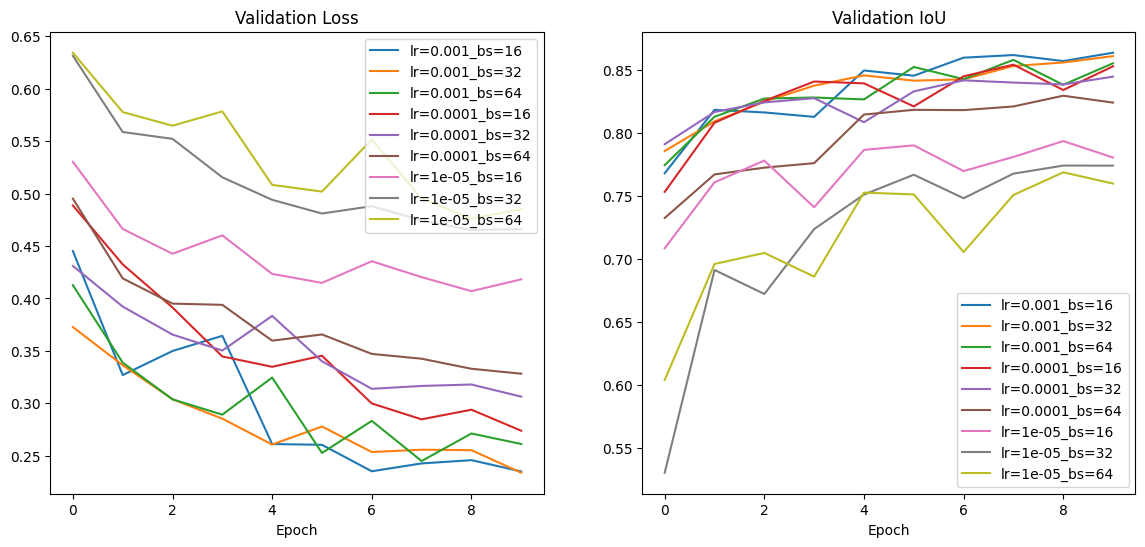

In [9]:
plt.figure(figsize=(14, 6))

# LOSS
plt.subplot(1, 2, 1)
for key, history in all_histories.items():
    plt.plot(history["val_loss"], label=key)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.legend()

# IOU
plt.subplot(1, 2, 2)
for key, history in all_histories.items():
    plt.plot(history["val_iou"], label=key)
plt.title("Validation IoU")
plt.xlabel("Epoch")
plt.legend()

plt.show()

# Мысли

lr 1e-05 слишком маленький
lr 1e-03 не слишком большой для данного эксперимента (на 10 эпох) тк приходит к лучшим метрикам но может проиграть на большем количестве эпох

bs 64 градиенты очень стабильные, медленная генерализация
bs 16 самые шумные градиенты поэтому лучшая генерализация

In [15]:
best_lr = float(df.iloc[0]["lr"])
best_batch_size = int(df.iloc[0]["batch_size"])

cfg = copy.deepcopy(config)
cfg.learning_rate = best_lr
cfg.batch_size = best_batch_size
cfg.epochs = 15

def run_one_experiment(backbone_name):
    trainer = Trainer(cfg)

    trainer.model = UNet(backbone_name=backbone_name).to(cfg.device)
    trainer.optimizer = optim.Adam(trainer.model.parameters(), lr=cfg.learning_rate)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_iou": [],
        "val_f1": []
    }

    for epoch in range(cfg.epochs):
        train_loss = trainer.train()
        val_loss, val_iou, val_f1 = trainer.validate()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)
        history["val_f1"].append(val_f1)

        print(
            f"[{backbone_name}] epoch {epoch+1}/{cfg.epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"val_iou={val_iou:.4f} | val_f1={val_f1:.4f}"
        )

    test_loss, test_iou, test_f1 = trainer.test()

    return trainer, history, {
        "backbone": backbone_name,
        "test_loss": test_loss,
        "test_iou": test_iou,
        "test_f1": test_f1
    }

trainer34, hist34, res34 = run_one_experiment("resnet34")
trainer50, hist50, res50 = run_one_experiment("resnet50")

results_compare = pd.DataFrame([res34, res50]).sort_values("test_iou", ascending=False)
results_compare

/opt/homebrew/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:05<00:00,  8.69it/s]


[resnet34] epoch 1/15 | train_loss=0.3029 | val_loss=0.2914 | val_iou=0.8435 | val_f1=0.9086


100%|██████████| 46/46 [00:05<00:00,  8.73it/s]


[resnet34] epoch 2/15 | train_loss=0.2140 | val_loss=0.2370 | val_iou=0.8624 | val_f1=0.9200


100%|██████████| 46/46 [00:05<00:00,  8.60it/s]


...

[resnet50] epoch 14/15 | train_loss=0.0815 | val_loss=0.1885 | val_iou=0.9018 | val_f1=0.9448


100%|██████████| 46/46 [00:06<00:00,  7.14it/s]


[resnet50] epoch 15/15 | train_loss=0.0889 | val_loss=0.1707 | val_iou=0.9110 | val_f1=0.9508


100%|██████████| 230/230 [00:35<00:00,  6.54it/s]


,backbone,test_loss,test_iou,test_f1
1,resnet50,0.170937,0.911112,0.950416
0,resnet34,0.209611,0.888026,0.935554


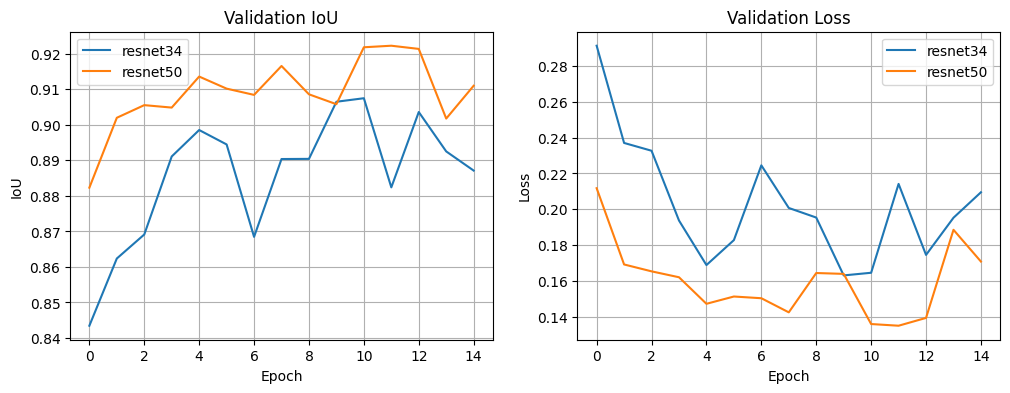

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.99215686].


Best backbone: resnet50


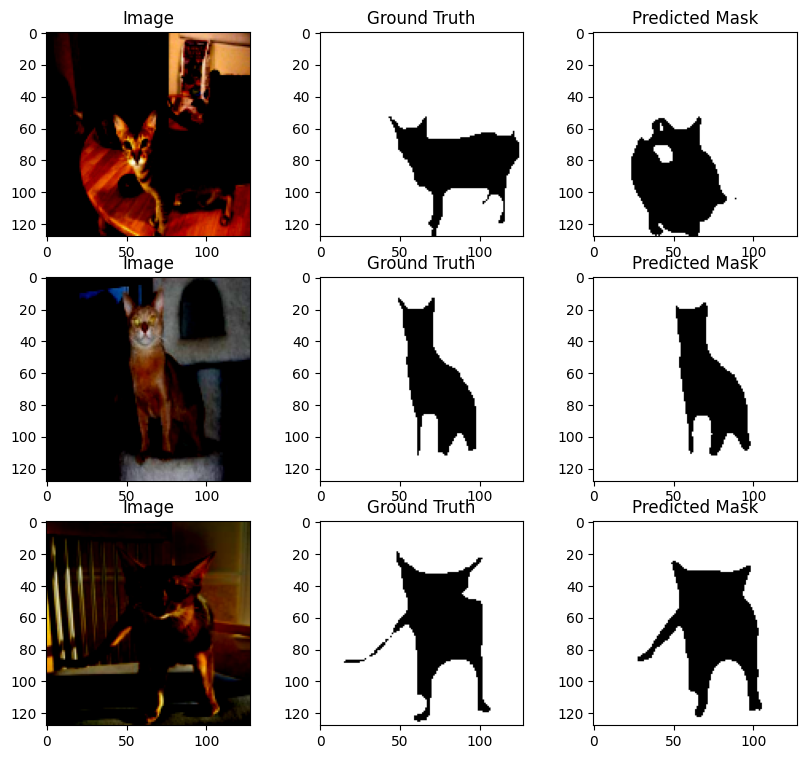

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist34["val_iou"], label="resnet34")
plt.plot(hist50["val_iou"], label="resnet50")
plt.title("Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist34["val_loss"], label="resnet34")
plt.plot(hist50["val_loss"], label="resnet50")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.show()

best_backbone = results_compare.iloc[0]["backbone"]
print("Best backbone:", best_backbone)

if best_backbone == "resnet34":
    trainer34.inference_and_plot_samples(n_samples=3)
else:
    trainer50.inference_and_plot_samples(n_samples=3)

# Мысли

Более глубокий бэкбон лучше генерализует и чуть быстрее сходится, профит